In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer      # ✅ built-in, no CSV needed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)
%matplotlib inline

print("✅ All libraries imported!")

✅ All libraries imported!


In [21]:
# ── Load directly from sklearn ─────────────────────────────────────────
cancer = load_breast_cancer()

# Put into a clean DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target                  # 0 = Malignant, 1 = Benign

print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"🎯 Target classes: {cancer.target_names}")   # ['malignant' 'benign']
df.head()

📐 Shape: 569 rows × 31 columns
🎯 Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,0
1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,0
2,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,0
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,0
4,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077,0


In [23]:
# ── Basic info ─────────────────────────────────────────────────────────
print("=" * 55)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [25]:
# ── Statistical summary ────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


In [27]:
# ── Check missing values ───────────────────────────────────────────────
print("Missing values:", df.isnull().sum().sum())   # should be 0 ✅

Missing values: 0


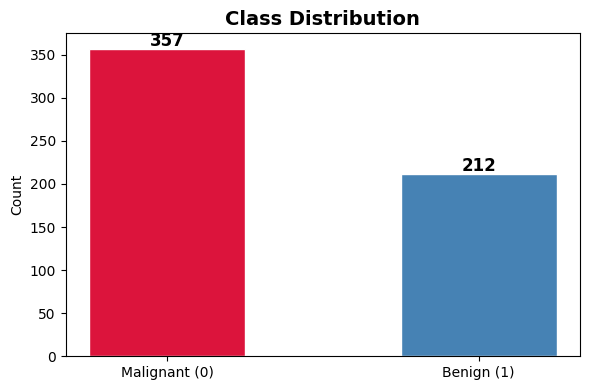

In [29]:
# ── Class distribution ─────────────────────────────────────────────────
counts = df['target'].value_counts()
labels = ['Malignant (0)', 'Benign (1)']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, counts.values, color=['crimson', 'steelblue'],
               edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(val), ha='center', fontsize=12, fontweight='bold')

plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

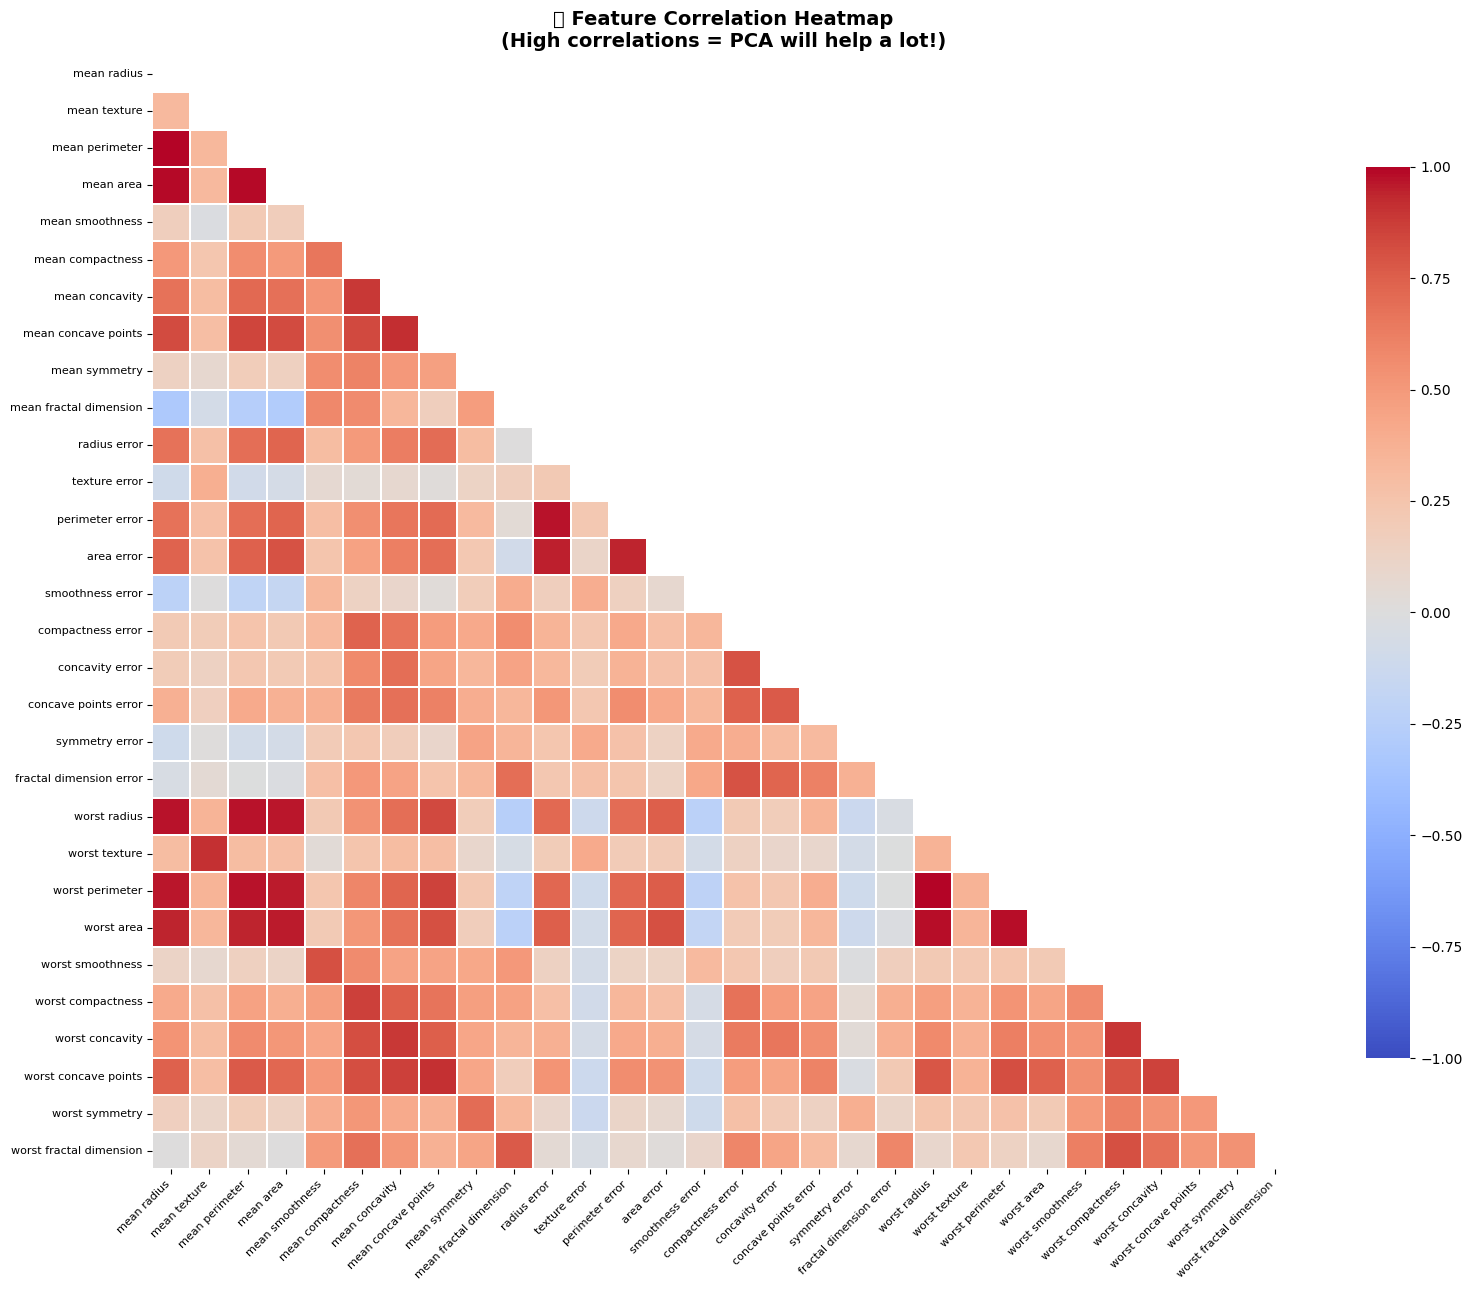

⚠️  Feature pairs with |correlation| > 0.8: 44
👉 This is exactly why PCA is powerful here!


In [31]:
# ── Shows WHY we need PCA — many features are highly correlated ────────
plt.figure(figsize=(16, 13))

corr = df.drop('target', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})

plt.title('🔗 Feature Correlation Heatmap\n(High correlations = PCA will help a lot!)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── Count highly correlated pairs ──────────────────────────────────────
high_corr = (corr.abs() > 0.8).sum().sum() - 30   # subtract diagonal
print(f"⚠️  Feature pairs with |correlation| > 0.8: {high_corr // 2}")
print("👉 This is exactly why PCA is powerful here!")

In [33]:
# ── Separate features from target ─────────────────────────────────────
X = df.drop('target', axis=1)     # 30 features
y = df['target']                   # labels (0 or 1)

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (569, 30)
Target shape   : (569,)


In [35]:
# ── Standardize: mean=0, std=1 for every feature ──────────────────────
# CRITICAL for PCA — without this, features with larger values dominate

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ After scaling:")
print(f"   Mean ≈ {X_scaled.mean():.6f}  (should be ≈ 0)")
print(f"   Std  ≈ {X_scaled.std():.6f}   (should be ≈ 1)")


✅ After scaling:
   Mean ≈ -0.000000  (should be ≈ 0)
   Std  ≈ 1.000000   (should be ≈ 1)


In [37]:
# ── Fit PCA with ALL 30 components first ──────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

# ── Print variance table ───────────────────────────────────────────────
print(f"{'PC':<6} {'Variance %':<14} {'Cumulative %'}")
print("─" * 35)
for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    tag = " ◀ 80%" if abs(c - 0.80) == min(abs(cumulative - 0.80)) else \
          " ◀ 90%" if abs(c - 0.90) == min(abs(cumulative - 0.90)) else \
          " ◀ 95%" if abs(c - 0.95) == min(abs(cumulative - 0.95)) else ""
    print(f"PC{i:<4} {e*100:>9.2f}%   {c*100:>9.2f}%  {tag}")

PC     Variance %     Cumulative %
───────────────────────────────────
PC1        44.27%       44.27%  
PC2        18.97%       63.24%  
PC3         9.39%       72.64%  
PC4         6.60%       79.24%   ◀ 80%
PC5         5.50%       84.73%  
PC6         4.02%       88.76%  
PC7         2.25%       91.01%   ◀ 90%
PC8         1.59%       92.60%  
PC9         1.39%       93.99%  
PC10        1.17%       95.16%   ◀ 95%
PC11        0.98%       96.14%  
PC12        0.87%       97.01%  
PC13        0.80%       97.81%  
PC14        0.52%       98.34%  
PC15        0.31%       98.65%  
PC16        0.27%       98.92%  
PC17        0.20%       99.11%  
PC18        0.18%       99.29%  
PC19        0.16%       99.45%  
PC20        0.10%       99.56%  
PC21        0.10%       99.66%  
PC22        0.09%       99.75%  
PC23        0.08%       99.83%  
PC24        0.06%       99.89%  
PC25        0.05%       99.94%  
PC26        0.03%       99.97%  
PC27        0.02%       99.99%  
PC28        0.01%   

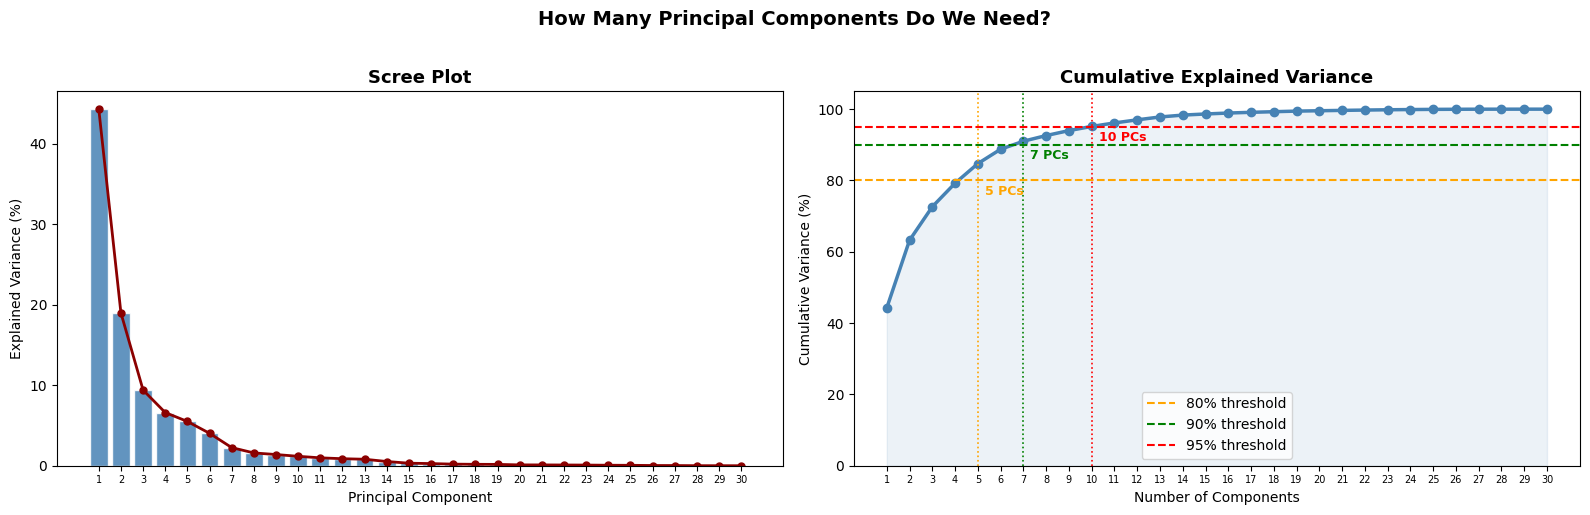

📌 80% variance retained with just 5 components  (reduced from 30 → 5, saving 25 features!)
📌 90% variance retained with just 7 components  (reduced from 30 → 7, saving 23 features!)
📌 95% variance retained with just 10 components  (reduced from 30 → 10, saving 20 features!)


In [39]:
# ── Scree Plot + Cumulative Variance ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Scree Plot ---
ax1.bar(range(1, 31), explained * 100,
        color='steelblue', edgecolor='white', alpha=0.85)
ax1.plot(range(1, 31), explained * 100,
         'o-', color='darkred', lw=2, ms=5)
ax1.set_title('Scree Plot', fontsize=13, fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_xticks(range(1, 31))
ax1.tick_params(axis='x', labelsize=7)

# --- Right: Cumulative Variance ---
ax2.plot(range(1, 31), cumulative * 100,
         'o-', color='steelblue', lw=2.5, ms=6)
ax2.fill_between(range(1, 31), cumulative * 100, alpha=0.1, color='steelblue')

for threshold, color, label in [(80, 'orange', '80%'),
                                  (90, 'green',  '90%'),
                                  (95, 'red',    '95%')]:
    ax2.axhline(y=threshold, color=color, linestyle='--', lw=1.5, label=f'{label} threshold')
    n = np.argmax(cumulative >= threshold/100) + 1
    ax2.axvline(x=n, color=color, linestyle=':', lw=1.2)
    ax2.text(n + 0.3, threshold - 4, f'{n} PCs', color=color, fontsize=9, fontweight='bold')

ax2.set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_xticks(range(1, 31))
ax2.tick_params(axis='x', labelsize=7)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 105])

plt.suptitle('How Many Principal Components Do We Need?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
for t in [0.80, 0.90, 0.95]:
    n = np.argmax(cumulative >= t) + 1
    print(f"📌 {int(t*100)}% variance retained with just {n} components  "
          f"(reduced from 30 → {n}, saving {30-n} features!)")

In [41]:
# ── We use 2 components so we can plot it easily ───────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y.values
df_pca['diagnosis'] = df_pca['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"✅ Reduced: 30 features → 2 components")
print(f"   PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"   PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"   Total retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
df_pca.head()

✅ Reduced: 30 features → 2 components
   PC1 explains: 44.3%
   PC2 explains: 19.0%
   Total retained: 63.2%


,PC1,PC2,target,diagnosis
0,9.193,1.949,0,Malignant
1,2.388,-3.768,0,Malignant
2,5.734,-1.075,0,Malignant
3,7.123,10.276,0,Malignant
4,3.935,-1.948,0,Malignant


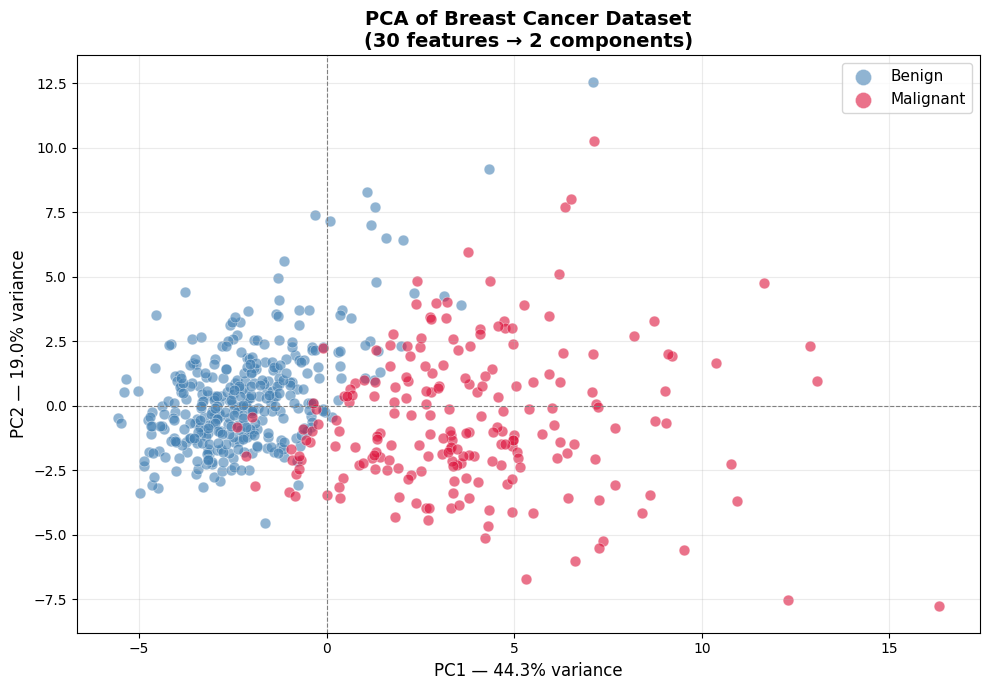

💡 Notice how clearly PCA separates Malignant from Benign — using just 2 numbers!


In [43]:
# ── 2D Scatter: Can PCA separate Malignant vs Benign? ─────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Malignant': 'crimson', 'Benign': 'steelblue'}

for diagnosis, group in df_pca.groupby('diagnosis'):
    ax.scatter(group['PC1'], group['PC2'],
               label=diagnosis,
               color=colors[diagnosis],
               alpha=0.6, s=60,
               edgecolors='white', linewidth=0.4)

ax.set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance", fontsize=12)
ax.set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance", fontsize=12)
ax.set_title('PCA of Breast Cancer Dataset\n(30 features → 2 components)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.axhline(0, color='grey', linestyle='--', lw=0.8)
ax.axvline(0, color='grey', linestyle='--', lw=0.8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("💡 Notice how clearly PCA separates Malignant from Benign — using just 2 numbers!")